# Quick Load and Predict

Minimal notebook: load the trained model, load one degraded image, run
prediction, view the result. For a fuller test suite (batch processing,
quantitative metrics, multiple examples), see `Proposed_Model_Testing.ipynb`
instead — this notebook is intentionally the smallest possible working example.

In [2]:
import sys, os
sys.path.insert(0, "..")

import torch
import numpy as np
import matplotlib.pyplot as plt

from models.restoration_net import DistributionMixtureRestorationNet


## 1. Load the trained model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

CHECKPOINT_PATH = "../DistributionMixtureRestorationNet.pth"

model = DistributionMixtureRestorationNet(base_ch=32, n_components=3,
                                            n_lr_blocks=4, n_hr_blocks=2, use_film=True)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device).eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"Best validation PSNR: {checkpoint['best_val_psnr']:.3f}")
print(f"Best validation SSIM: {checkpoint['best_val_ssim']:.4f}")


## 2. Load one degraded image

Set `IMAGE_PATH` to a real `.npy` file (128x128, float32) before running.

In [ ]:
IMAGE_PATH = r"path\to\one\degraded_image.npy"   # <-- CHANGE THIS

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(
        f"{IMAGE_PATH} does not exist -- set IMAGE_PATH to a real degraded .npy file before continuing."
    )

degraded = np.load(IMAGE_PATH).astype(np.float32)
print("Loaded image shape:", degraded.shape, " dtype:", degraded.dtype)


## 3. Predict (restore)

In [ ]:
with torch.no_grad():
    x = torch.from_numpy(degraded).unsqueeze(0).unsqueeze(0).to(device)  # [1, 1, H, W]
    restored, mix_weights, beta, scale = model(x)
    restored_np = restored[0, 0].clamp(0, 1).cpu().numpy()

print("Input shape: ", degraded.shape)
print("Output shape:", restored_np.shape)
print("Output range: [{:.4f}, {:.4f}]".format(restored_np.min(), restored_np.max()))


## 4. Visualize

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(degraded, cmap="gray")
axes[0].set_title("Degraded (input)")
axes[0].axis("off")

axes[1].imshow(restored_np, cmap="gray")
axes[1].set_title("Restored (output)")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../results/quick_predict_example.png", dpi=150)
plt.show()
print("Saved: ../results/quick_predict_example.png")


## 5. (Optional) Save the restored image

Uncomment and run to save the output as its own `.npy` file.

In [ ]:
# out_path = "../results/quick_predict_output.npy"
# np.save(out_path, restored_np.astype(np.float32))
# print("Saved:", out_path)


In [5]:
import sys, os
sys.path.insert(0, "..")

import numpy as np
import torch

from models.restoration_net import DistributionMixtureRestorationNet

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = DistributionMixtureRestorationNet(base_ch=32, n_components=3,
                                            n_lr_blocks=4, n_hr_blocks=2, use_film=True)

CKPT_PATH = "../results/checkpoints/DistributionMixtureRestorationNet.pth"
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device).eval()
print(f"Loaded checkpoint: {CKPT_PATH}")

device: cpu
Loaded checkpoint: ../results/checkpoints/DistributionMixtureRestorationNet.pth


device: cpu
Loaded checkpoint: ../results/checkpoints/DistributionMixtureRestorationNet.pth


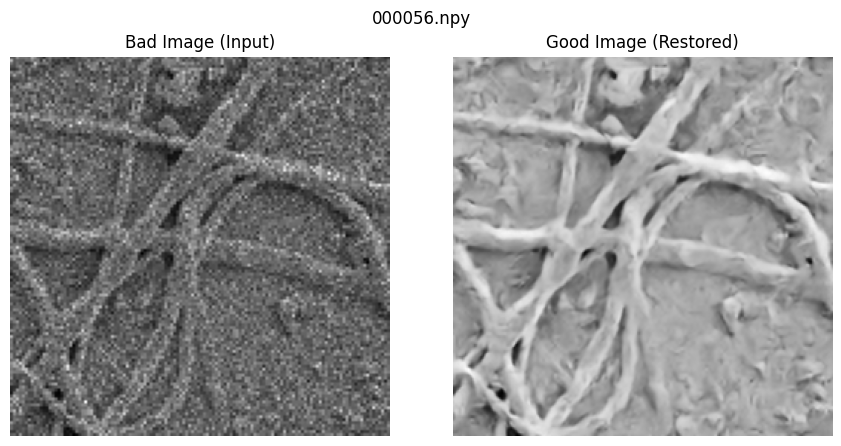

(array([[0.57181835, 0.57118636, 0.93197715, ..., 0.43970087, 0.29792145,
         0.34009874],
        [1.14279   , 0.55281174, 0.61222965, ..., 0.4562479 , 0.43453988,
         0.65163493],
        [0.7099245 , 0.52466697, 0.6878477 , ..., 0.7048694 , 0.5718896 ,
         0.6827231 ],
        ...,
        [0.65273035, 0.47658587, 0.43956047, ..., 0.68214357, 0.62673813,
         0.70385766],
        [0.36250135, 0.34748667, 0.5870777 , ..., 0.5318091 , 0.43087587,
         0.63786966],
        [0.60373074, 0.65800047, 0.4232998 , ..., 0.56429315, 0.6933023 ,
         0.57368594]], shape=(128, 128), dtype=float32),
 array([[0.6324863 , 0.64163214, 0.6566598 , ..., 0.40013117, 0.39409456,
         0.38401026],
        [0.6889785 , 0.65976304, 0.6609022 , ..., 0.43112957, 0.43253636,
         0.43170905],
        [0.7460252 , 0.6849098 , 0.66191614, ..., 0.47810233, 0.4950207 ,
         0.5269727 ],
        ...,
        [0.48600397, 0.48604044, 0.4897197 , ..., 0.57631   , 0.5969662 ,
 

In [32]:

import sys, os
sys.path.insert(0, "..")

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from models.restoration_net import DistributionMixtureRestorationNet


device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


CKPT_PATH = "../results/checkpoints/DistributionMixtureRestorationNet.pth"
model = DistributionMixtureRestorationNet(base_ch=32, n_components=3,
                                            n_lr_blocks=4, n_hr_blocks=2, use_film=True)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device).eval()
print(f"Loaded checkpoint: {CKPT_PATH}")


@torch.no_grad()
def restore_image(noisy_np):
    x = torch.from_numpy(noisy_np.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)
    restored, mix_weights, beta, scale = model(x)
    restored_np = restored[0, 0].clamp(0, 1).cpu().numpy()
    return restored_np, mix_weights[0].cpu().numpy(), beta.cpu().numpy()


TARGET_SIZE = 256 

def load_any(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".npy":
        return np.load(path).astype(np.float32)
    elif ext in (".png", ".jpg", ".jpeg"):
        img = Image.open(path).convert("L")
        if img.size != (TARGET_SIZE, TARGET_SIZE):
            img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.BILINEAR)
        return np.asarray(img, dtype=np.float32) / 255.0
    else:
        raise ValueError(f"Unsupported file type: {ext}")


def test_on_file(path):
    bad_img = load_any(path)
    good_img, mix_weights, beta = restore_image(bad_img)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(bad_img, cmap="gray"); axes[0].set_title("Bad Image (Input)"); axes[0].axis("off")
    axes[1].imshow(good_img, cmap="gray"); axes[1].set_title("Good Image (Restored)"); axes[1].axis("off")
    fig.suptitle(os.path.basename(path))
    plt.tight_layout()
    plt.show()

    return bad_img, good_img


test_on_file(r"D:\RESEARCH PAPERS\Semi_Conductor_2\Semi conductor image paper\Phase-2\semicon_train_data\NoisyLR\000056.npy")